In [16]:
import sys
import os
# Add the scripts folder to the path
sys.path.append(os.path.abspath("scripts"))

# Import functions
from data_processing import convert_all_nc4_to_csv, load_combined_dataframe, get_season
from spatial_analysis import (filter_by_africa_bounds, get_africa_shape, 
                              create_geodataframe_from_grid, clip_to_africa,
                              create_geodataframe_polygons, extract_land_cover)
from visualization import (plot_monthly_grid, plot_annual_mean_map, 
                           plot_seasonal_maps, plot_monthly_timeseries, 
                           plot_co2_by_land_cover)


In [17]:
# 1. Processing
convert_all_nc4_to_csv("data", "data_csv")

Processed 362 files.


In [18]:
df_all = load_combined_dataframe("data_csv")

In [19]:
# 2. DATA LOADING
df_africa = filter_by_africa_bounds(df_all)
df_africa["season"] = df_africa["month"].apply(get_season)  
africa_shape = get_africa_shape("data_shapefile/africa_boundaries.shp")

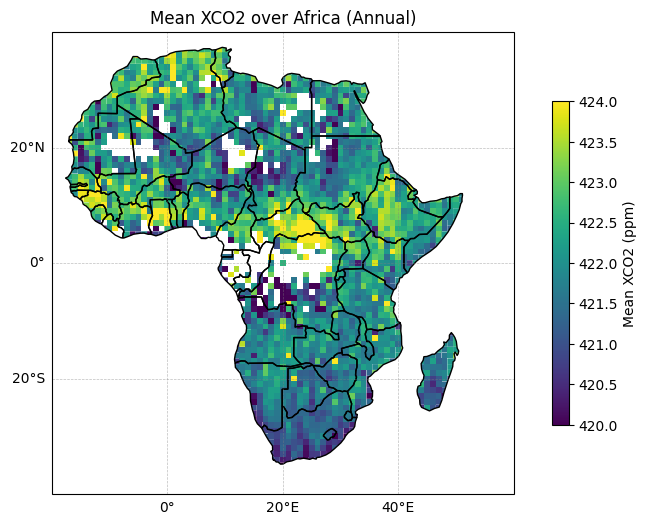

In [20]:
# 3. Annual Plot
gdf_poly = create_geodataframe_polygons(df_africa)
gdf_annual = clip_to_africa(gdf_poly, africa_shape)
plot_annual_mean_map(gdf_annual, africa_shape)

In [46]:
import geopandas as gpd
gdf_with_country = gpd.sjoin(
    gdf_annual, 
    africa_shape[['geometry', 'ADMIN']],  # ou le champ avec les noms des pays
    how='left',
    predicate='within'
)

# print(africa_shape.columns)
# print(africa_shape.head()) # le champs où il y a les noms des pays c'est "ADMIN"
print(len(africa_shape))
print(gdf_with_country['ADMIN'].unique())

50
<StringArray>
[                               nan,                     'South Africa',
                          'Namibia',                         'Botswana',
                       'Mozambique',                         'Zimbabwe',
                           'Angola',                           'Zambia',
 'Democratic Republic of the Congo',      'United Republic of Tanzania',
            'Republic of the Congo',         'Central African Republic',
                       'Madagascar',                            'Kenya',
                          'Somalia',                           'Uganda',
                      'South Sudan',                            'Gabon',
                'Equatorial Guinea',                         'Cameroon',
                          'Nigeria',                            'Sudan',
                             'Chad',                            'Niger',
                          'Algeria',                            'Libya',
                            'Egypt

In [62]:
country_section = {
    # 🌴 TROPICAL
    'Nigeria': 'Tropical',
    'Ghana': 'Tropical',
    'Ivory Coast': 'Tropical',
    'Liberia': 'Tropical',
    'Sierra Leone': 'Tropical',
    'Guinea': 'Tropical',
    'Guinea-Bissau': 'Tropical',
    'Cameroon': 'Tropical',
    'Central African Republic': 'Tropical',
    'Equatorial Guinea': 'Tropical',
    'Gabon': 'Tropical',
    'Republic of the Congo': 'Tropical',
    'Democratic Republic of the Congo': 'Tropical',
    'Uganda': 'Tropical',
    'Kenya': 'Tropical',
    'United Republic of Tanzania': 'Tropical',
    'Benin': 'Tropical',
    'Mozambique': 'Tropical',
    'Madagascar': 'Tropical',
    'Senegal': 'Tropical',
    'Zimbabwe': 'Temperate',
    'Zambia': 'Temperate',
    'Angola': 'Temperate',

    # 🌵 ARID (sahara, sahel)
    'Algeria': 'Arid',
    'Libya': 'Arid',
    'Egypt': 'Arid',
    'Sudan': 'Arid',
    'South Sudan': 'Arid',
    'Chad': 'Arid',
    'Niger': 'Arid',
    'Mali': 'Arid',
    'Mauritania': 'Arid',
    'Namibia': 'Arid',
    'Botswana': 'Arid',
    'Somalia': 'Arid',
    'Somaliland': 'Arid',
    'Eritrea': 'Arid',

    # 🌿 TEMPERATE (sud de l’Afrique)
    'South Africa': 'Temperate',

    # 🌊 MEDITERRANEAN (Nord Afrique)
    'Morocco': 'Mediterranean',
    'Tunisia': 'Mediterranean',

    # 🌍 TRANSITION 
    'Burkina Faso': 'Arid',
    'Ethiopia': 'Arid'
}
gdf_with_country['climate_zone'] = gdf_with_country['ADMIN'].map(country_section)

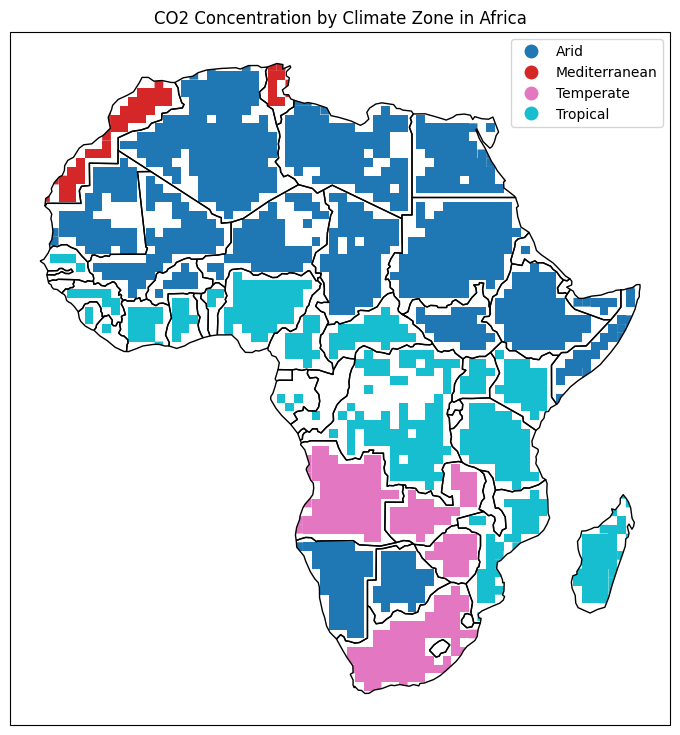

893
<StringArray>
[nan]
Length: 1, dtype: str


In [63]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': ccrs.PlateCarree()})
gdf_with_country.plot(ax=ax, column='climate_zone', legend=True, categorical=True, cmap="tab10")
africa_shape.boundary.plot(ax=ax, edgecolor='black', linewidth=1)
plt.title("CO2 Concentration by Climate Zone in Africa")
plt.show()

print(gdf_with_country['climate_zone'].isna().sum())
print(gdf_with_country[gdf_with_country['climate_zone'].isna()]['ADMIN'].unique())

In [64]:
zones = africa_shape.copy()

zones['climate_zone'] = zones['ADMIN'].map(country_section)

# enlever les pays non classés
zones_clean = zones.dropna(subset=['climate_zone'])

In [65]:
zones_dissolved = zones_clean.dissolve(by='climate_zone')

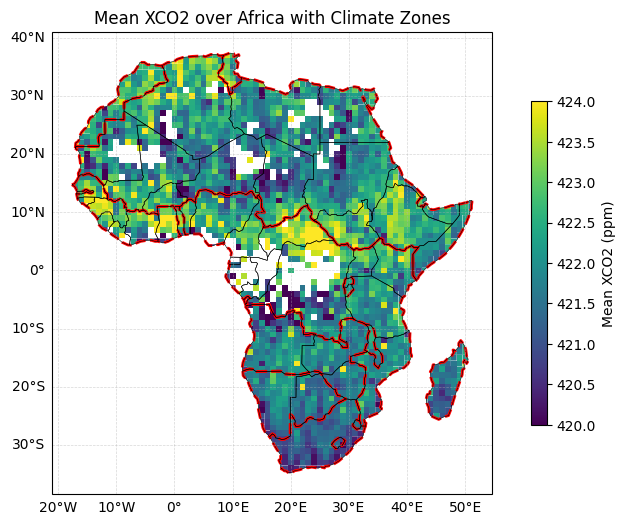

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# CO2 (ta carte principale)
gdf_annual.plot(
    ax=ax,
    column="xco2",
    cmap="viridis",
    vmin=420, vmax=424,
    legend=True,
    legend_kwds={'label': "Mean XCO2 (ppm)", 'shrink': 0.7}
)

# zones climatiques (juste contours)
zone_colors = {
    'Tropical': 'green',
    'Arid': 'orange',
    'Temperate': 'blue',
    'Mediterranean': 'purple'
}
for zone, color in zone_colors.items():
    zones_dissolved.loc[[zone]].boundary.plot(
        ax=ax,
        edgecolor=color,
        linewidth=2,
        linestyle='--'
    )

legend_lines = [
    Line2D([0], [0], color=color, lw=2, linestyle='--', label=zone)
    for zone, color in zone_colors.items()
]

ax.legend(
    handles=legend_lines,
    title="Climate Zones",
    loc='lower left'
)

# frontières Afrique
africa_shape.boundary.plot(ax=ax, edgecolor='black', linewidth=0.4)

# latitude / longitude (optionnel mais propre)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.title("Mean XCO2 over Africa with Climate Zones")
plt.show()

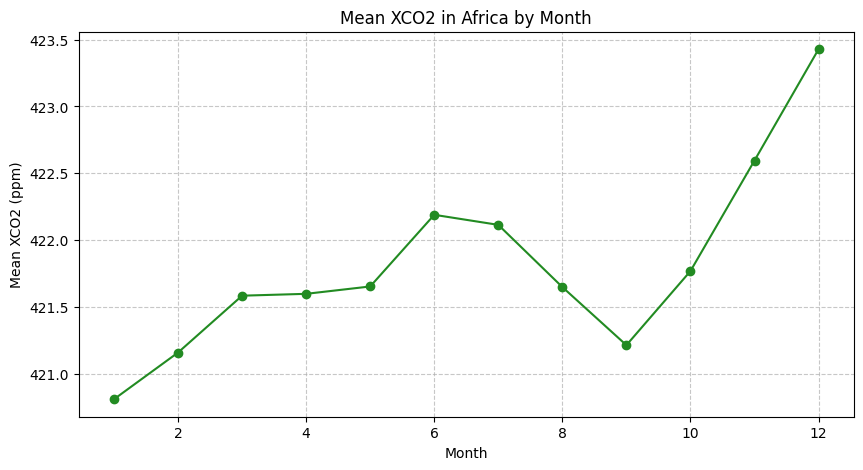

In [22]:
# 4. Monthly timeseries
plot_monthly_timeseries(df_africa)

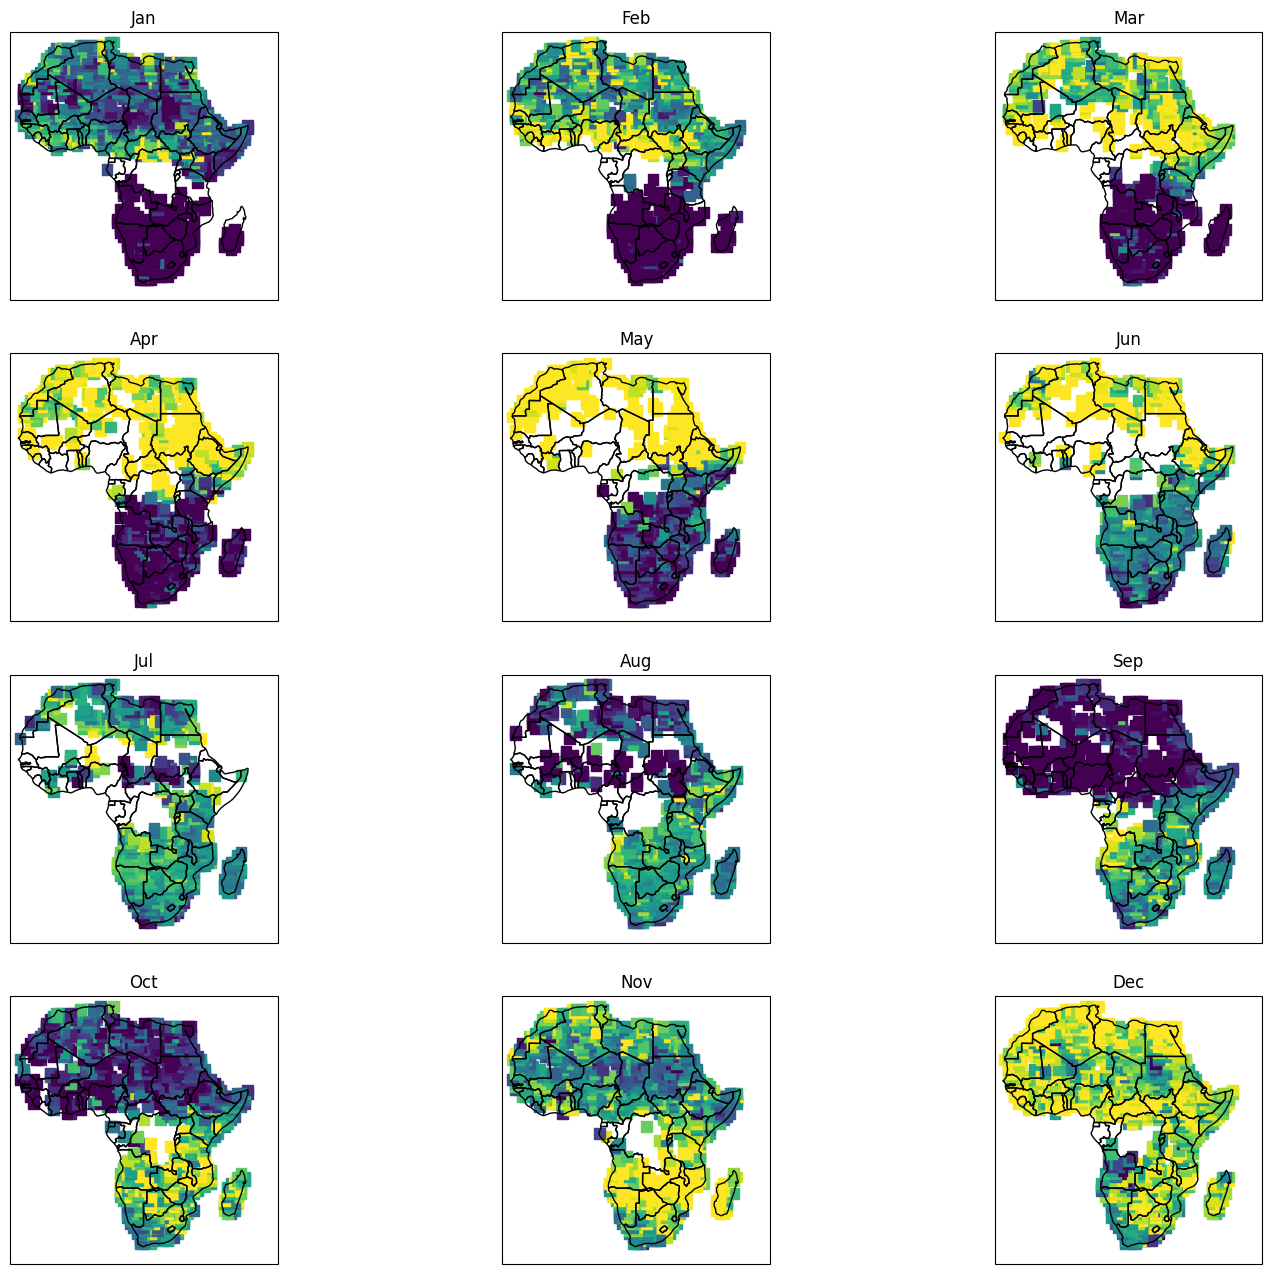

In [23]:
# --- 5. MONTHLY GRID MAPS ---
gdf_points = create_geodataframe_from_grid(df_africa)
gdf_final_points = clip_to_africa(gdf_points, africa_shape)
plot_monthly_grid(gdf_final_points, africa_shape)

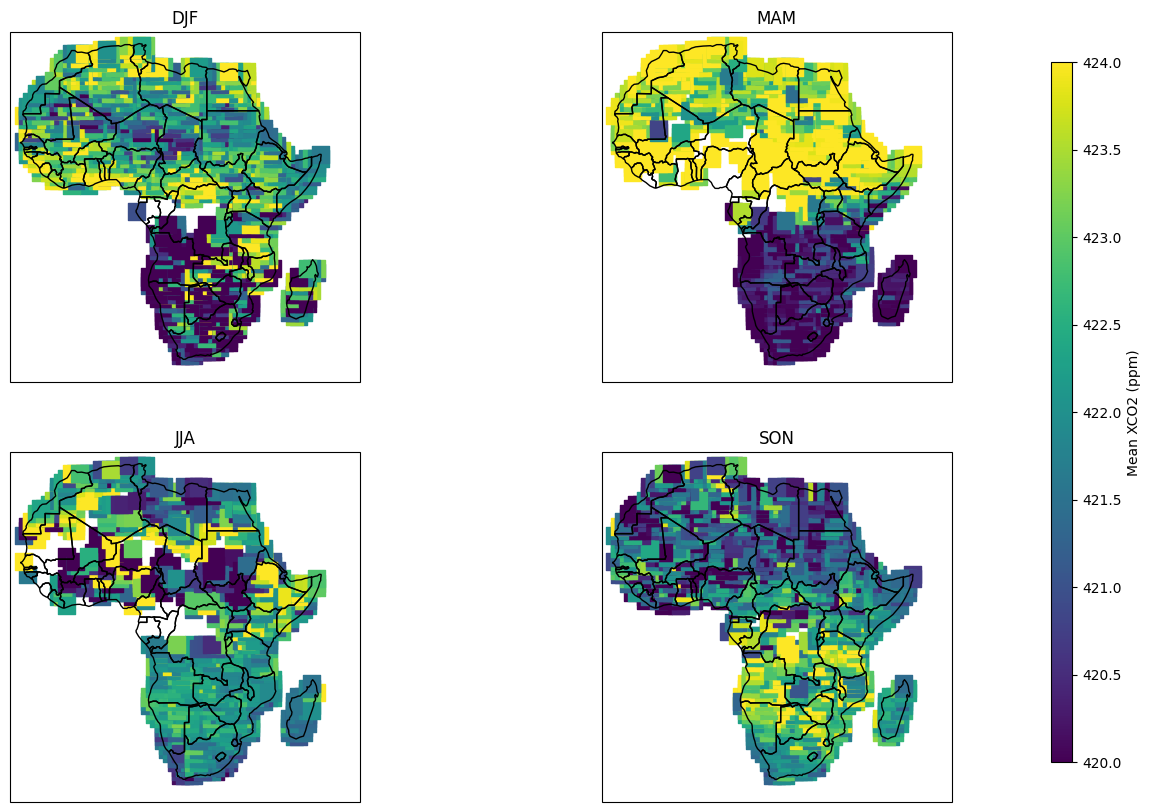

In [24]:
# --- 6. SEASONAL MAPS ---
plot_seasonal_maps(df_africa, africa_shape)

In [25]:
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np

In [26]:
tif_path = "data_raster/land_cover_africa_2.tif"
with rasterio.open(tif_path) as src:
    lc_data = src.read(
        1,
        out_shape=(
            1,
            src.height // 10,   # reduce resolution by factor 10
            src.width // 10
        )
    )
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    
palette = [
    "#1d0dff00",'#05450a','#086a10','#54a708','#78d203','#009900',
    '#c6b044','#dcd159','#dade48','#fbff13','#b6ff05',
    '#27ff87','#c24f44','#a5a5a5','#ff6d4c','#69fff8',
    '#f9ffa4']
labels = ['Water','Evergreen Needleleaf Forest','Evergreen Broadleaf Forest','Deciduous Needleleaf Forest',
    'Deciduous Broadleaf Forest','Mixed Forest','Closed Shrublands','Open Shrublands',
    'Woody Savannas','Savannas','Grasslands','Permanent Wetlands','Croplands','Urban',
    'Cropland/Natural Mosaic','Snow/Ice','Barren']

#colormap
cmap = ListedColormap(palette)


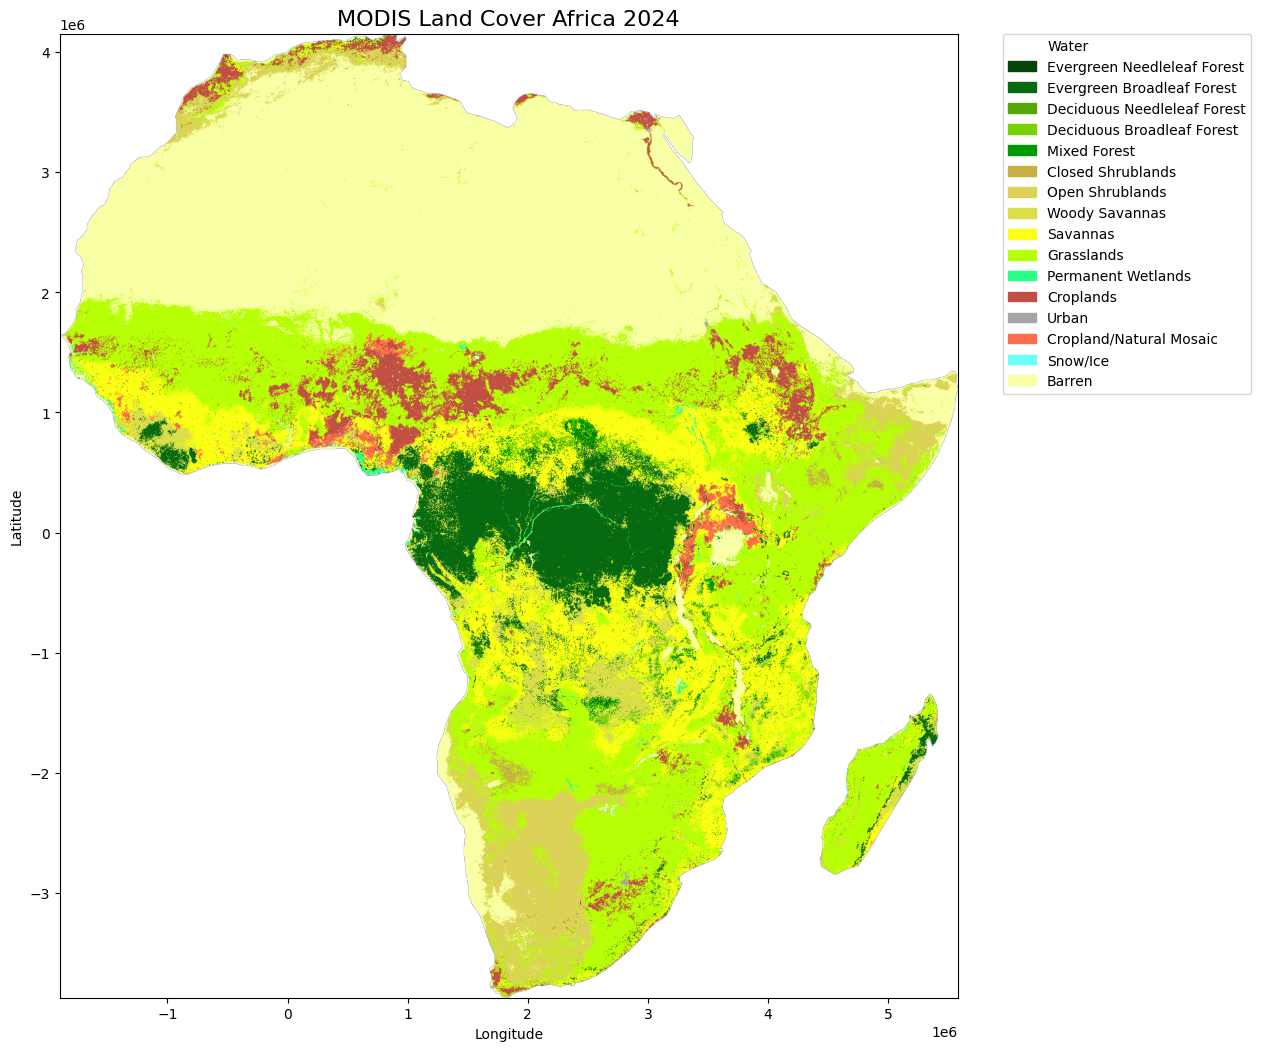

In [27]:
#plot the raster
plt.figure(figsize=(12,12))
im = plt.imshow(lc_data, cmap=cmap, vmin=0, vmax=17, extent=extent)
plt.title("MODIS Land Cover Africa 2024", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# add legend
patches = [Patch(color=palette[i], label=labels[i]) for i in range(len(labels))]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)

plt.tight_layout()
plt.savefig("./results/land_cover_africa.png", dpi=300, bbox_inches='tight')
plt.show()